## Visualizing Diagnostical Terminology
After processing our dataset, we chose to visualize the 'diagnostic keyword'. Our main goal is to highlight common terms and compare them with the original data. This will help us understand the differences between the cleaned and raw datasets.

### Importing necessary libraries

In [1]:
# Uncomment and Install if not present
#!pip install wordcloud

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

### Load and process data file

In [5]:
# Loading the processed dataset into a DataFrame
df = pd.read_excel("../Processed_data.xlsx")

In [6]:
# Split the 'Diagnosis' column into a list of diagnoses
concatanated_values = ','.join(df['Diagnosis'])

In [7]:
# Remove non alphabetic characters
new_string = re.sub(r'[^a-zA-Z, ]', '', concatanated_values).split(',')
# Trim words in the list
trimmed_words = [word.strip() for word in new_string]

In [8]:
# Create a dictionary to store word counts.
word_counts = {}

# Count word occurrences
for word in trimmed_words:
    if word in word_counts:
        word_counts[word] += 1
    else:
        word_counts[word] = 1
        

In [9]:
# Sort the word counts by count in descending order and select the top 10
sorted_word_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:10]

# Convert the sorted word counts to a DataFrame
df_wordcount = pd.DataFrame(sorted_word_counts, columns=['Words', 'Counts'])

df_wordcount

,Words,Counts
0,normal fundus,3100
1,moderate non proliferative retinopathy,997
2,mild nonproliferative retinopathy,552
3,lens dust,408
4,cataract,313
5,glaucoma,282
6,pathological myopia,246
7,dry agerelated macular degeneration,228
8,macular epiretinal membrane,201
9,hypertensive retinopathy,193


### The visuals of the word count

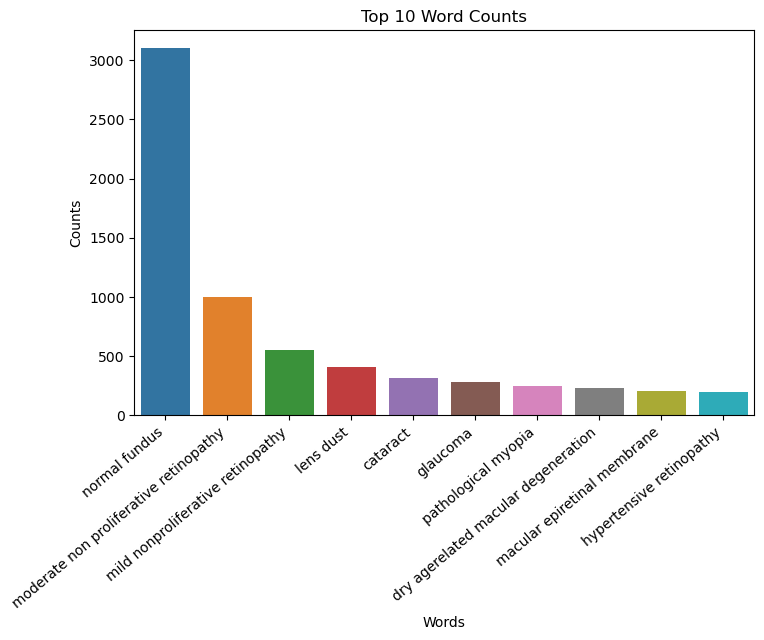

In [12]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Words', y='Counts', data=df_wordcount)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")  
plt.xlabel('Words')
plt.ylabel('Counts')
plt.title('Top 10 Word Counts')

plt.show()

### Analysis
The processed data reveals that "Normal Fundus" is the predominant diagnostic term, appearing 3,100 times, indicating a substantial number of normal eye findings. "Moderate Non Proliferative Retinopathy" and "Mild Nonproliferative Retinopathy" follow as the next frequent terms, reflecting the commonality of retinopathy conditions. Other prevalent diagnoses include "Lens Dust," suggesting image artifacts, and significant eye diseases such as "Cataract" and "Glaucoma". The presence of terms like "Pathological Myopia" and "Dry Age-related Macular Degeneration" further showcase the diversity of eye conditions in the dataset. The data offers a comprehensive view of the variety and prevalence of eye diagnoses in the sample dataset

In [8]:
from wordcloud import WordCloud

In [7]:
%reload_ext watermark

In [9]:
%watermark --iversions

re        : 2.2.1
seaborn   : 0.12.2
matplotlib: 3.7.2
pandas    : 2.0.3



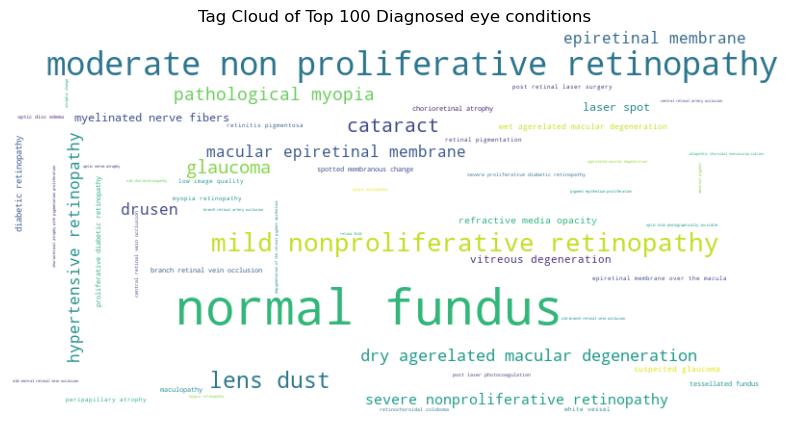

In [69]:
sorted_word_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:100]
# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(sorted_word_counts))

# Plot the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Tag Cloud of Top 100 Diagnosed eye conditions')
plt.show()

### Analysis

The tag cloud showcases the top 100 diagnosed eye conditions. Prominently, "Normal Fundus" stands out as the most frequent diagnosis, suggesting many normal eye findings. The terms "Moderate Non Proliferative Retinopathy" and "Mild Nonproliferative Retinopathy" also hold significant visual weight, indicating their common occurrence. Conditions like "Glaucoma," "Cataract," and "Dry Age-related Macular Degeneration" are also evident, highlighting their prevalence.